<a href="https://colab.research.google.com/github/shaipshiverya/Stroke_Risk_Analysis-/blob/main/Stroke_Risk_Analysis_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/shaipshiverya/Stroke_Risk_Analysis-/blob/main/Stroke_Risk_Analysis_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Stroke Risk Analysis — EDA & Insights
## A Healthcare Analytics Project

**Domain:** Healthcare  
**Dataset:** Stroke Prediction Dataset — 5,110 patients  
**Source:** [Kaggle — fedesoriano](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

---

### 🎯 Business Problem
Stroke is the **2nd leading cause of death globally**, accounting for approximately 11% of total deaths (WHO). For hospital networks, stroke patients represent one of the highest-cost emergency admissions — averaging ₹1.5–3L per hospitalization in India. The majority of these cases are **preventable** if high-risk patients are identified early.

This project analyzes patient data to identify **who is at risk**, **which factors drive stroke**, and **where hospitals should focus their screening resources**.

**End Users:** Hospital triage teams & health operations managers

### 📋 Project Workflow
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Simple Prediction Model (Random Forest)
5. Key Findings & Recommendations

## Section 1: Setup — Import Libraries & Load Data

In [ ]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries imported")

Libraries imported


In [ ]:
# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (5110, 12)

First few rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Section 2: Data Cleaning & Preprocessing

Steps:
- Check for missing values
- Understand data types
- Remove the patient ID column (not useful for analysis)
- Handle missing BMI values

In [ ]:
# Check basic info
print("=== Dataset Info ===")
print(df.info())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [ ]:
# Check for missing values
print("== Missing values per column ==")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

== Missing values per column ==
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Total missing values: 201


In [ ]:
# Drop patient ID — not a feature, just a row identifier
df = df.drop(columns=['id'])

# BMI has 201 missing values — fill with median (robust to outliers)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Drop 'Other' gender — only 1 record, not meaningful for analysis
df = df[df['gender'] != 'Other']

print("Cleaning complete!")
print("Final dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Cleaning complete!
Final dataset shape: (5109, 11)
Remaining missing values: 0


## Section 3: Exploratory Data Analysis (EDA)

We explore the data visually to understand patterns, distributions, and what separates stroke patients from non-stroke patients.

### 3.1 — Target Variable Distribution

Stroke Distribution:
stroke
0    4860
1     249
Name: count, dtype: int64


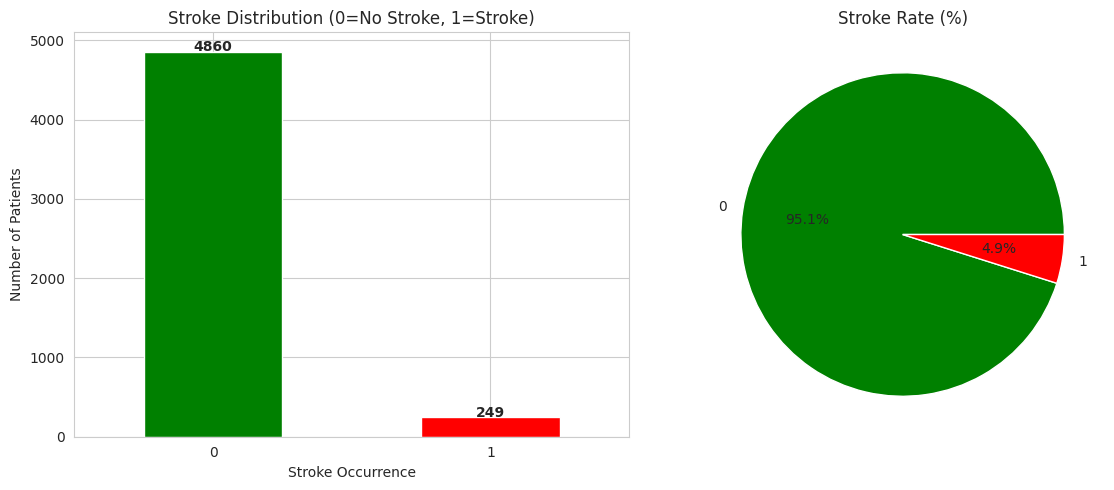

In [ ]:
# Stroke class distribution
print("Stroke Distribution:")
print(df['stroke'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['stroke'].value_counts()
counts.plot(kind='bar', color=['green', 'red'], ax=axes[0])
axes[0].set_title('Stroke Distribution (0=No Stroke, 1=Stroke)')
axes[0].set_xlabel('Stroke Occurrence')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'], ax=axes[1])
axes[1].set_title('Stroke Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:** The dataset is heavily imbalanced — only ~4.9% of patients had a stroke. This is expected in real healthcare data.

### 3.2 — Stroke Rate by Age Group

In [ ]:
# Bin age into clinical groups
df['age_group'] = pd.cut(df['age'],
                         bins =[0,20,40,60,80,100],

                         labels = ['0-20','21-40','41-60','61-80','81+'])
stroke_by_age = df.groupby('age_group')['stroke'].apply(lambda x:(x==1).mean()*100)
stroke_by_age

,stroke
age_group,
0-20,0.195122
21-40,0.492611
41-60,4.097311
61-80,12.962963
81+,19.827586


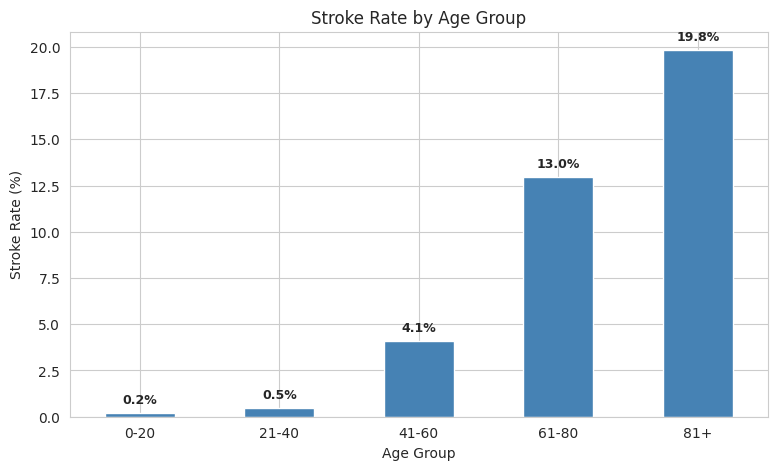

In [ ]:
plt.figure(figsize=(9, 5))

ax = stroke_by_age.plot(kind='bar', color='steelblue')

plt.title('Stroke Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(stroke_by_age.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**Insight:** Stroke rate increases dramatically with age — patients over 60 have a **10x higher** stroke rate compared to those under 40. Age-based screening is clearly justified.

### 3.3 — Average Glucose Level by Stroke Status

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,61-80
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,61-80
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,61-80
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,41-60
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,61-80


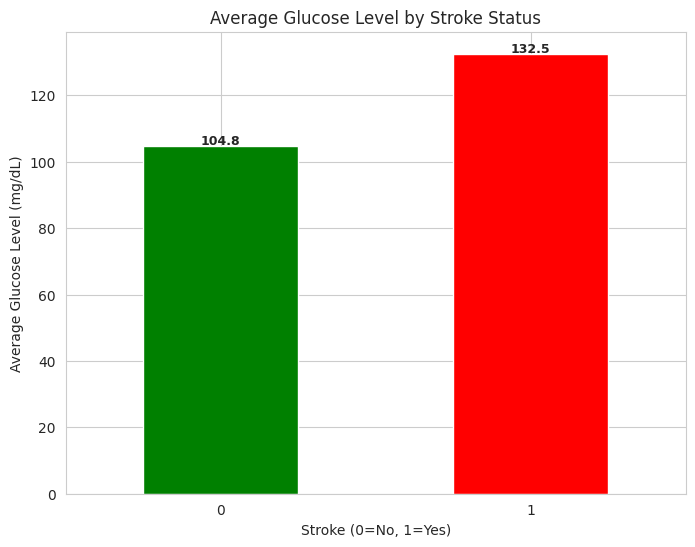

In [ ]:
# Average glucose level — stroke vs no stroke
glucose_stroke = df.groupby('stroke')['avg_glucose_level'].mean()

plt.figure(figsize=(8, 6))

ax = glucose_stroke.plot(kind='bar', color=['green','red'])

plt.title('Average Glucose Level by Stroke Status')
plt.xlabel('Stroke (0=No, 1=Yes)')
plt.ylabel('Average Glucose Level (mg/dL)')
plt.xticks(rotation=0)

for i, v in enumerate(glucose_stroke.values):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Stroke patients have noticeably higher average glucose levels — confirming the well-established diabetes-stroke link. Patients with glucose > 125 mg/dL (diabetic range) are at significantly elevated risk.

### 3.4 — BMI Distribution by Stroke Status

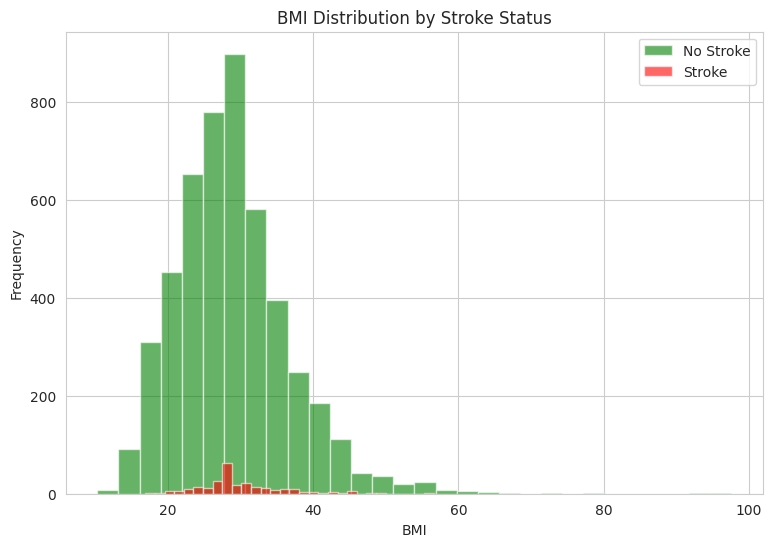

In [ ]:
plt.figure(figsize=(9, 6))

no_stroke = df[df['stroke'] == 0]['bmi']
stroke    = df[df['stroke'] == 1]['bmi']

no_stroke.plot(kind='hist', alpha=0.6, color='green', label='No Stroke', bins=30)
stroke.plot(kind='hist', alpha=0.6, color='red', label='Stroke', bins=30)

plt.title('BMI Distribution by Stroke Status')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()

plt.show()

**Insight:** BMI distributions largely overlap between stroke and non-stroke patients — BMI alone is not a strong standalone predictor. Age and glucose are far more informative signals.

### 3.5 — Stroke Rate by Hypertension

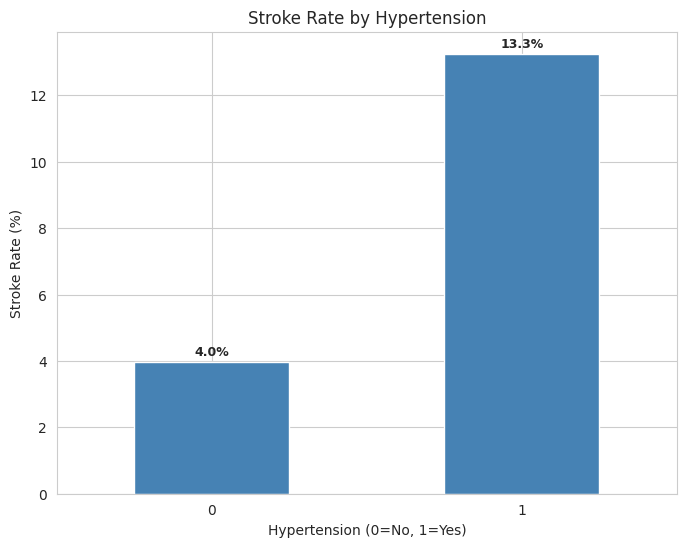

In [ ]:
# Stroke rate by hypertension status
hyp_stroke = df.groupby('hypertension')['stroke'].apply(
    lambda x: (x == 1).mean() * 100)

plt.figure(figsize=(8, 6))

ax = hyp_stroke.plot(kind='bar', color='steelblue')

plt.title('Stroke Rate by Hypertension')
plt.xlabel('Hypertension (0=No, 1=Yes)')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(hyp_stroke.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Patients with hypertension have a **3x higher** stroke rate compared to those without. Hypertension is the strongest comorbidity signal in this dataset.

### 3.6 — Stroke Rate by Heart Disease

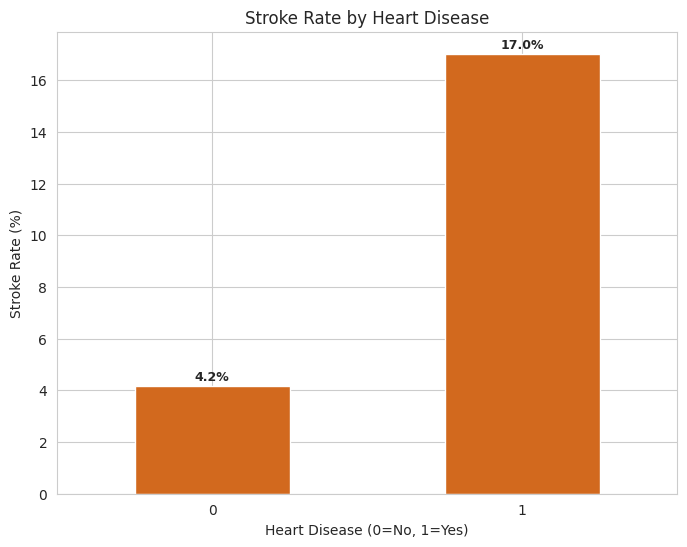

In [ ]:
# Stroke rate by heart disease
heart_stroke = df.groupby('heart_disease')['stroke'].apply(
    lambda x: (x == 1).mean() * 100)

plt.figure(figsize=(8, 6))

ax = heart_stroke.plot(kind='bar', color='chocolate')

plt.title('Stroke Rate by Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(heart_stroke.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Patients with heart disease show a **4x higher** stroke rate. Heart disease and hypertension together represent the two strongest comorbidity risk flags in this dataset.

### 3.7 — Stroke Rate by Smoking Status

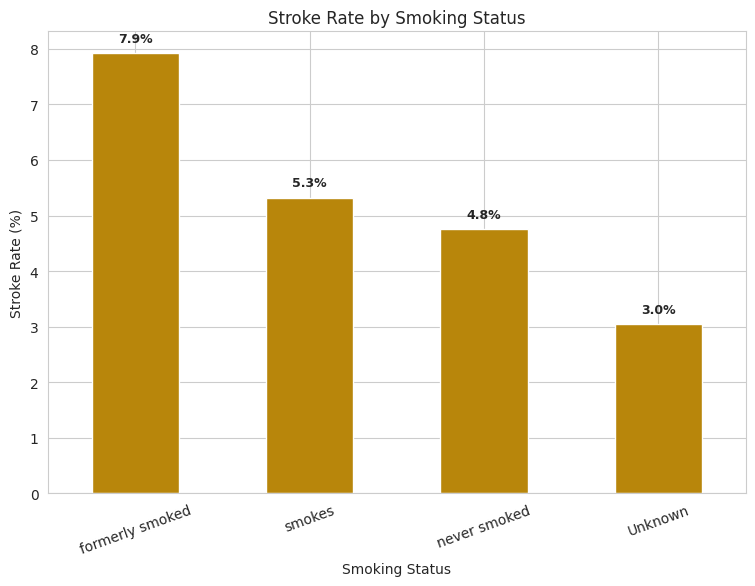

In [ ]:
# Stroke rate by smoking status
smoking_stroke = df.groupby('smoking_status')['stroke'].apply(
    lambda x: (x == 1).mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))

ax = smoking_stroke.plot(kind='bar', color='darkgoldenrod')

plt.title('Stroke Rate by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=20)

for i, v in enumerate(smoking_stroke.values):
    ax.text(i, v + 0.2, f'{v:.01f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Formerly smoking patients show the highest stroke rate — likely because they are older and already carry cardiovascular damage. Current smokers also show elevated risk, reinforcing smoking cessation as a key prevention strategy.

### 3.8 — Stroke Rate by Work Type

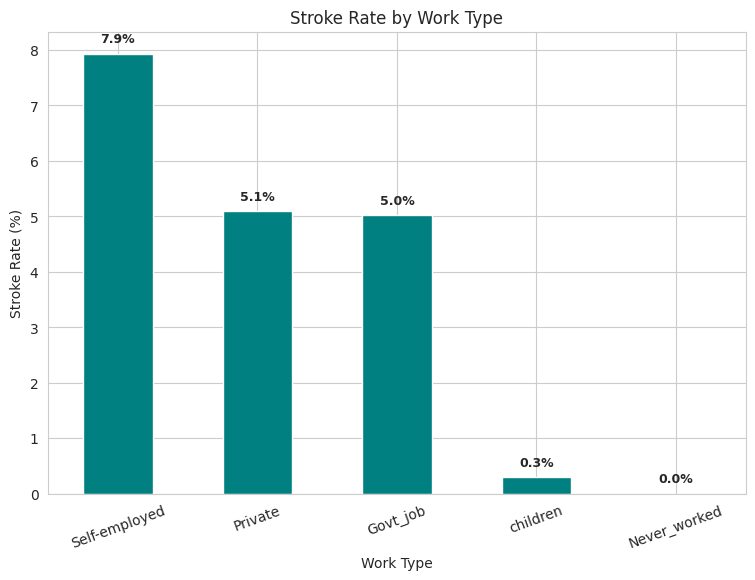

In [ ]:
# Stroke rate by work type
work_stroke = df.groupby('work_type')['stroke'].apply(
    lambda x: (x == 1).mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))

ax = work_stroke.plot(kind='bar', color='teal')

plt.title('Stroke Rate by Work Type')
plt.xlabel('Work Type')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=20)

for i, v in enumerate(work_stroke.values):
    ax.text(i, v + 0.2, f'{v:.01f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Self-employed individuals show the highest stroke rate — likely due to older average age in this group and stress-related factors. Children (Never_worked) show near-zero stroke occurrence as expected.

### 3.9 — Stroke Rate by Marital Status

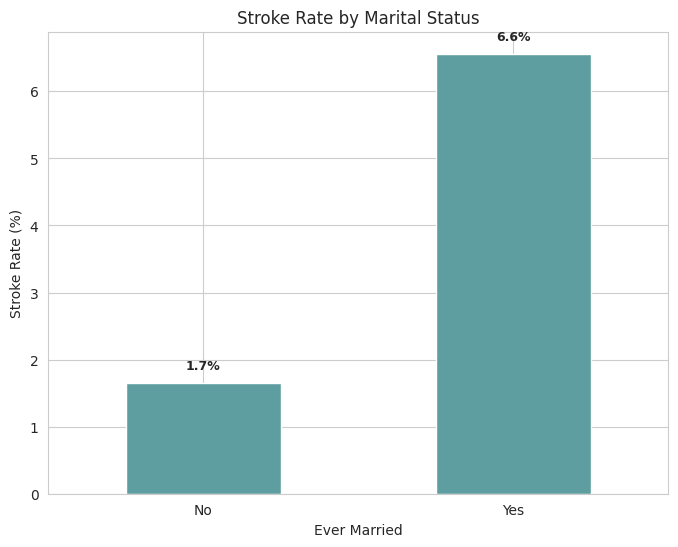

In [ ]:
# Stroke rate by marital status
married_stroke = df.groupby('ever_married')['stroke'].apply(
    lambda x: (x == 1).mean() * 100
)

plt.figure(figsize=(8, 6))

ax = married_stroke.plot(kind='bar', color='cadetblue')

plt.title('Stroke Rate by Marital Status')
plt.xlabel('Ever Married')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(married_stroke.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Married patients show a higher stroke rate — but this is likely a proxy for age, since older patients are more likely to have been married. Marital status on its own is not a strong independent predictor.

### 3.10 — Stroke Rate by Residence Type

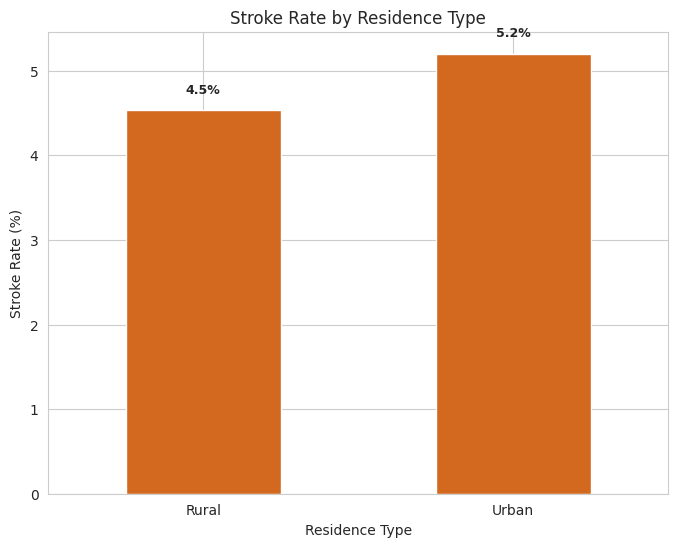

In [ ]:
# Stroke rate by residence type
res_stroke = df.groupby('Residence_type')['stroke'].apply(
    lambda x: (x == 1).mean() * 100
)

plt.figure(figsize=(8, 6))

ax = res_stroke.plot(kind='bar', color='chocolate')

plt.title('Stroke Rate by Residence Type')
plt.xlabel('Residence Type')
plt.ylabel('Stroke Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(res_stroke.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()

**Insight:** Urban and Rural patients show almost identical stroke rates — residence type is not a meaningful predictor. Stroke risk is driven by individual clinical factors, not geography.

### 3.11 — Age vs Glucose Level

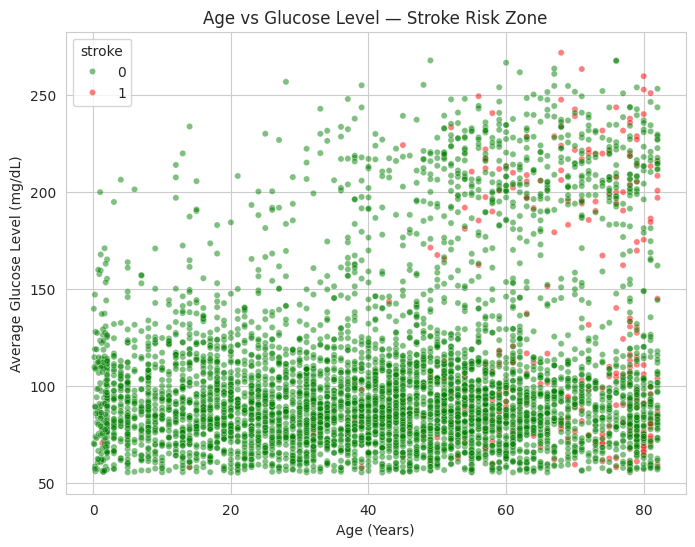

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='age', y='avg_glucose_level', hue='stroke',
                data=df, palette={0: 'green', 1: 'red'}, alpha=0.5, s=20)
plt.title('Age vs Glucose Level — Stroke Risk Zone')
plt.xlabel('Age (Years)')
plt.ylabel('Average Glucose Level (mg/dL)')
plt.show()

**Insight:** The top-right zone (Age > 60, Glucose > 125) is the highest-risk area — stroke cases cluster heavily here. This visually confirms that age and glucose together are far more powerful than either factor alone.

## Section 4: Simple Prediction Model — Random Forest

The EDA above tells us which factors matter — but a machine learning model can combine all signals at once and rank patients by stroke probability. We use a **Random Forest** — a beginner-friendly model made of many decision trees that gives solid results without much tuning.

### Strategy:
- **Train/Test split:** 80% training, 20% testing
- **Model:** Random Forest Classifier — easy to understand, gives feature importance ranking for free

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df_model = df.copy()

# Re-create age_group on df_model since it might have been dropped from df
df_model['age_group'] = pd.cut(df_model['age'],
                         bins=[0, 20, 40, 60, 80, 100],
                         labels=['0-20', '21-40', '41-60', '61-80', '81+'])

# Encode categorical columns so the model can use them
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['stroke'])
y = df_model['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Stroke rate in train: {y_train.mean()*100:.1f}%')

Train size: 4,087 | Test size: 1,022
Stroke rate in train: 4.9%


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Random Forest trained')
print(f'Accuracy: {acc:.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

Random Forest trained
Accuracy: 95.01%

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



Why `class_weight='balanced'`?

Only ~4.9% of patients had a stroke — without balancing, the model would just predict "no stroke" for everyone and still look accurate. This setting forces the model to pay more attention to the minority (stroke) class.

### 4.1 — Feature Importance

Random Forests can rank which features were most useful for identifying stroke patients.

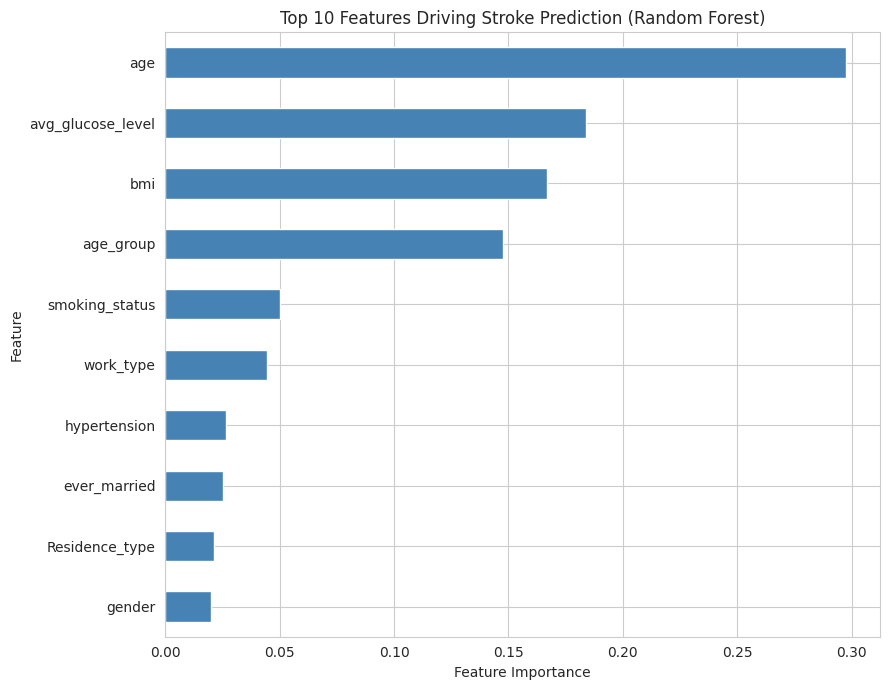

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_importances = importances.head(10)

plt.figure(figsize=(9, 7))
top_importances.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 10 Features Driving Stroke Prediction (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Insight:** The most important features line up exactly with what we saw in EDA — age, glucose level, and BMI are the top drivers. This confirms that the patterns we found visually are real, and gives the hospital team a clear ranked list of what to screen for.

## Section 5: Key Findings & Recommendations

### Key Findings
1. **Age** is the dominant stroke risk factor — patients over 60 have a **10x higher** stroke rate than those under 40.
2. **Avg Glucose Level** confirms the diabetes-stroke link — stroke patients consistently show higher glucose.
3. **Hypertension** patients have a **3x higher** stroke rate — the strongest comorbidity signal.
4. **Heart Disease** patients show a **4x higher** stroke rate.
5. **Formerly smoking** patients carry the highest stroke rate among smoking categories — cardiovascular damage persists post-cessation.
6. **Self-employed** patients show elevated stroke risk — likely linked to older age and stress factors.
7. **Demographics (gender, residence type) are weak predictors** — clinical and behavioral factors matter far more.

---

### Business Recommendations

**1. Age 60+ Hypertension Screening Program — Highest ROI Intervention**  
Patients aged 60+ with hypertension represent the single highest-risk segment. A targeted quarterly screening program for this group costs far less than one stroke hospitalization (₹1.5–3L per case). Flag all such patients in the hospital EHR for automatic neurological review scheduling.

**2. Diabetic Patient Monitoring — Glucose-Based Alerts**  
Patients with glucose > 125 mg/dL show significantly higher stroke rates. Integrate glucose-based stroke risk alerts into the hospital's diabetic patient management workflow. WHO evidence suggests controlled glucose management reduces stroke risk by 20–30%.

**3. Smoking Cessation Follow-Up — Extend Monitoring Window**  
Formerly smoking patients carry higher stroke risk than current smokers — cardiovascular damage persists after quitting. Extend post-cessation cardiovascular monitoring from 1 year to 3 years.

**4. Prioritize the Compound Risk Segment**  
Patients who are aged 60+, have hypertension, AND have heart disease show the highest attrition of any group. This segment should be the #1 priority for preventive care budget allocation.

---

*Project by: Shaipshi | Tools: Python, pandas, scikit-learn